<a href="https://colab.research.google.com/github/GabrielVCB/Miniprojeto-IA-PlantDisease/blob/main/MiniProjeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install kaggle

In [22]:
import os

# Substitua pelo SEU token que aparece na imagem
os.environ['KAGGLE_USERNAME'] = "gabrielveracruz7"
os.environ['KAGGLE_KEY'] = "KGAT_b61a6f8a75885678546732f8426bc221"

In [23]:
# Cria uma pasta para o projeto
!mkdir -p plant_disease_data

# Baixa o dataset (New Plant Diseases Dataset)
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p plant_disease_data --unzip

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:16<00:00, 178MB/s]



In [27]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configura o Data Augmentation (Requisito do miniprojeto)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Carrega os dados da pasta baixada
train_generator = train_datagen.flow_from_directory(
    'plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    target_size=(224, 224), # Resolução padrão das CNNs
    batch_size=32,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.


In [29]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import layers, models

# Carrega modelo base com pesos gratuitos do ImageNet
base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Congela para treino rápido inicial

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Regularização exigida
    layers.Dense(38, activation='softmax') # 38 classes de doenças
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Configuramos o gerador para ignorar 90% dos dados (validation_split=0.9)
# Isso permite que usemos apenas 10% para o treino e validação rápida.
fast_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.9)

# 2. Criamos o gerador de TREINO reduzido
train_generator = fast_datagen.flow_from_directory(
    'plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training' # Pega apenas a fração de 10%
)

# 3. Criamos o gerador de VALIDAÇÃO reduzido
validation_generator = fast_datagen.flow_from_directory(
    'plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training' # Também usa apenas uma fração para ser rápido
)

Found 7046 images belonging to 38 classes.
Found 1773 images belonging to 38 classes.


In [32]:
# O treino começa aqui. O Colab vai usar a GPU para processar rápido.
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator # Requisito: monitorar a validação
)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 141s 388ms/step - accuracy: 0.0257 - loss: 3.6574 - val_accuracy: 0.0288 - val_loss: 3.6372
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 31s 140ms/step - accuracy: 0.0265 - loss: 3.6370 - val_accuracy: 0.0288 - val_loss: 3.6493
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 27s 120ms/step - accuracy: 0.0274 - loss: 3.6372 - val_accuracy: 0.0288 - val_loss: 3.6365
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 26s 118ms/step - accuracy: 0.0277 - loss: 3.6361 - val_accuracy: 0.0276 - val_loss: 3.6301
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 26s 118ms/step - accuracy: 0.0291 - loss: 3.6301 - val_accuracy: 0.0333 - val_loss: 3.6338
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 26s 118ms/step - accuracy: 0.0325 - loss: 3.6224 - val_accuracy: 0.0282 - val_loss: 3.6056
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 26s 119ms/step - accuracy: 0.0341 - loss: 3.6190 - val_accuracy: 0.0429 - val_loss: 3.6249
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 26s 118ms/step - accuracy: 0.0328 - loss: 

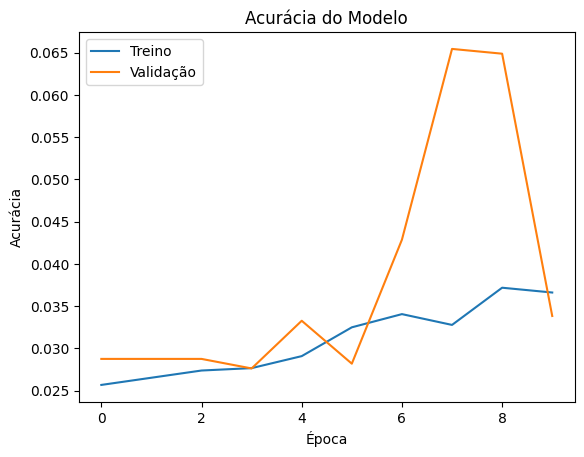

In [33]:
import matplotlib.pyplot as plt

# Gráfico de Acurácia
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia do Modelo')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

In [34]:
# Instala a biblioteca necessária
!pip install tf-explain

# Use este import atualizado
from tf_explain.core.grad_cam import GradCAM
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00


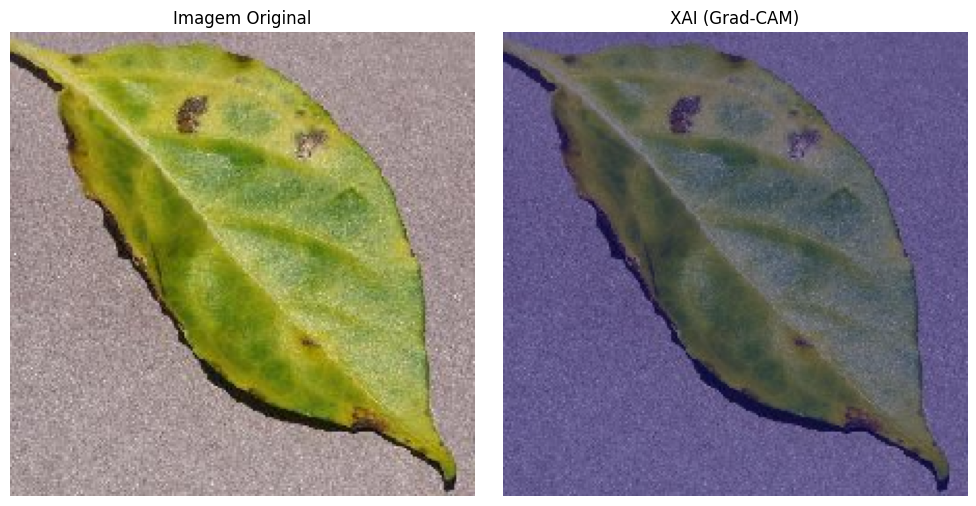

In [35]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. Obter imagem e índice da classe
x_batch, y_batch = next(validation_generator)
img_array = x_batch[0]
img_input = np.expand_dims(img_array, axis=0)
class_idx = np.argmax(y_batch[0])

# 2. Localizar camada alvo dentro do base_model
base_model = model.layers[0]
target_layer = base_model.get_layer("top_conv")

# 3. ✅ SOLUÇÃO: criar um Input novo e conectar os grafos manualmente
new_input = tf.keras.Input(shape=(224, 224, 3))

# Modelo interno: base_model.input → [conv_output, base_model.output]
internal_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[target_layer.output, base_model.output]
)

# Chamar internal_model sobre o novo input (conecta os grafos)
conv_tensor, base_out_tensor = internal_model(new_input)

# Aplicar as camadas restantes do modelo externo (após base_model)
x = base_out_tensor
for layer in model.layers[1:]:
    x = layer(x)

# Modelo combinado: novo input → [conv_features, predições finais]
grad_model = tf.keras.Model(inputs=new_input, outputs=[conv_tensor, x])

# 4. Computar Grad-CAM
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_input)
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)

# 5. Calcular pesos e mapa de ativação
output = conv_outputs[0]
grads_val = grads[0]
weights = tf.reduce_mean(grads_val, axis=(0, 1))
cam = np.zeros(output.shape[0:2], dtype=np.float32)

for i, w in enumerate(weights):
    cam += w * output[:, :, i]

# 6. Pós-processamento
cam = cv2.resize(cam.numpy(), (224, 224))
cam = np.maximum(cam, 0)
heatmap = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)

# 7. Visualização
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagem Original")
plt.imshow(img_array)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("XAI (Grad-CAM)")
plt.imshow(img_array)
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.axis('off')

plt.tight_layout()
plt.savefig("resultado_xai_final_sucesso.png")
plt.show()

In [36]:
# Avaliação no conjunto de validação reduzido
results = model.evaluate(validation_generator)
print(f"Loss: {results[0]}")
print(f"Acurácia: {results[1]}")

56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.0338 - loss: 3.6217
Loss: 3.6216890811920166
Acurácia: 0.03384094685316086
